<a href="https://colab.research.google.com/github/angeruzzi/statistics-studies/blob/main/RMSE_x_PEHE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

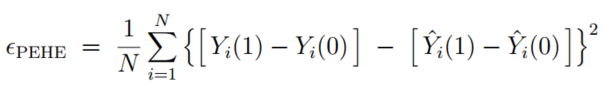

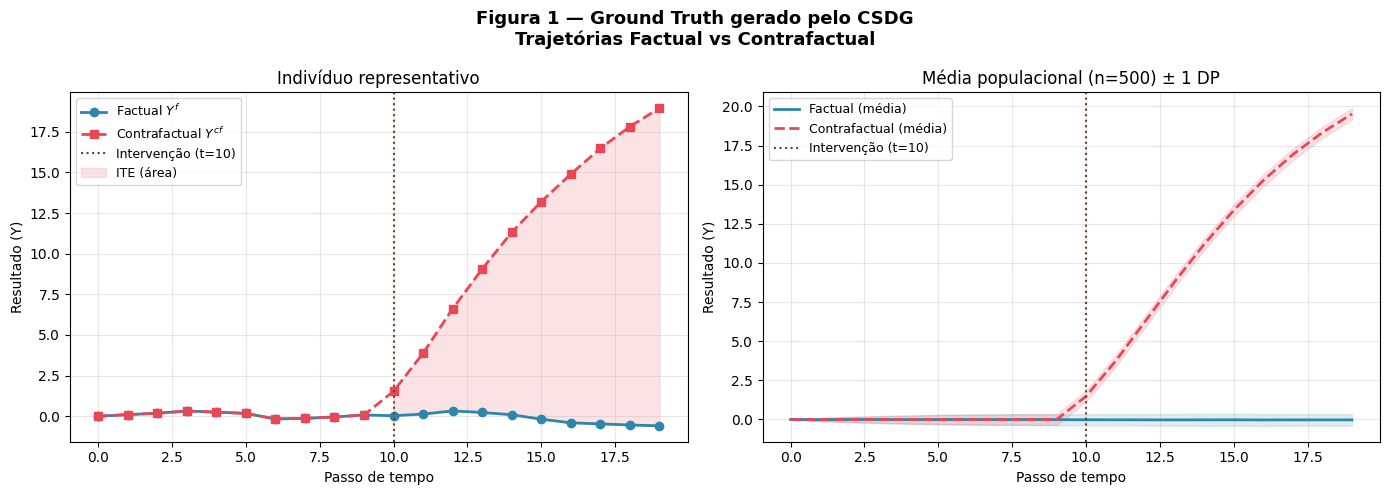

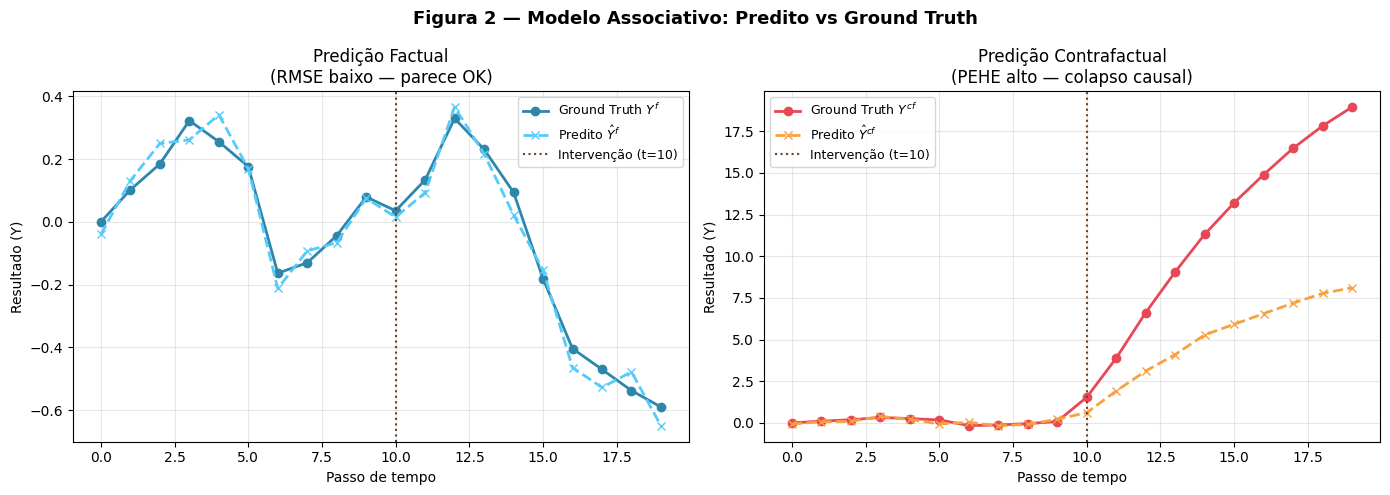

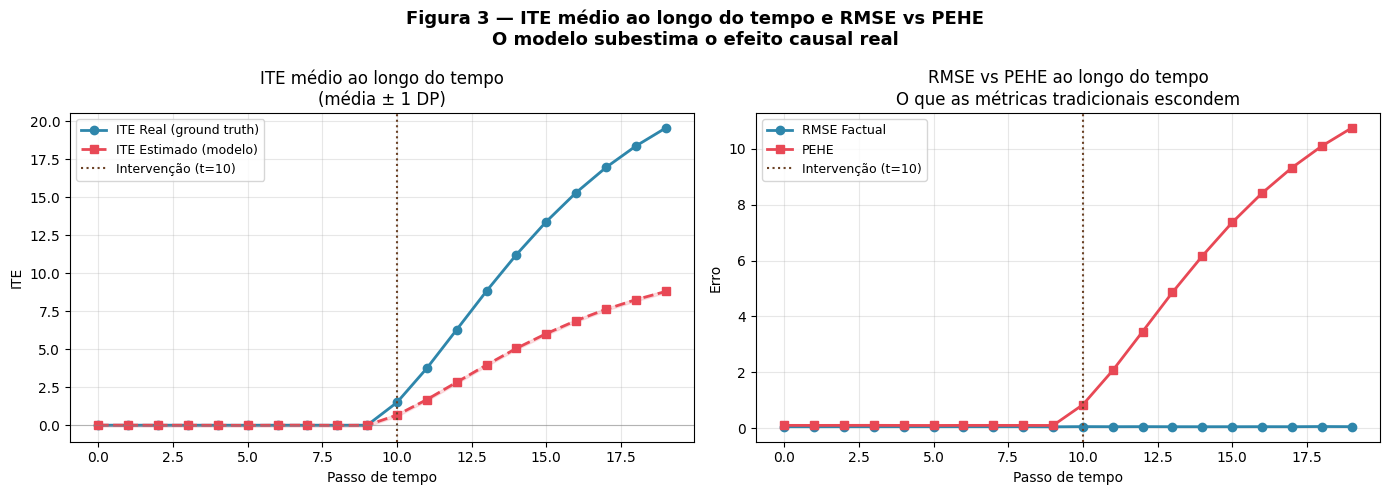

RESUMO DOS RESULTADOS
RMSE Factual médio  (pós t=10): 0.0499
PEHE médio          (pós t=10): 6.3362
ITE real  — média final (t=19): 19.546
ITE estim — média final (t=19): 8.794


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================================
# PARÂMETROS
# ============================================================
n       = 500   # indivíduos
T       = 20    # passos de tempo
t_int   = 10    # ponto de intervenção
phi_t   = 0.8   # persistência temporal do tratamento
phi_y   = 0.7   # persistência temporal do resultado
beta_ty = 1.5   # efeito causal T → Y
sigma   = 0.1   # amplitude do ruído uniforme

COLORS = {
    "factual":  "#2E86AB",
    "counter":  "#E84855",
    "pred_f":   "#56CBF9",
    "pred_cf":  "#F9A03F",
    "ite_true": "#2E86AB",
    "ite_est":  "#E84855",
    "rmse":     "#2E86AB",
    "pehe":     "#E84855",
    "interv":   "#6B4226",
}

# ============================================================
# SIMULAÇÃO
# ============================================================
def simulate(n, T, t_int, delta=0.0, noise_T=None, noise_Y=None):
    if noise_T is None:
        noise_T = np.random.uniform(-sigma, sigma, (n, T))
    if noise_Y is None:
        noise_Y = np.random.uniform(-sigma, sigma, (n, T))

    T_var = np.zeros((n, T))
    Y     = np.zeros((n, T))

    for t in range(1, T):
        T_var[:, t] = phi_t * T_var[:, t-1] + noise_T[:, t]
        if t >= t_int:
            T_var[:, t] += delta
        Y[:, t] = phi_y * Y[:, t-1] + beta_ty * T_var[:, t] + noise_Y[:, t]

    return T_var, Y

# Ruídos compartilhados — par factual/contrafactual com mesmo exógeno
noise_T = np.random.uniform(-sigma, sigma, (n, T))
noise_Y = np.random.uniform(-sigma, sigma, (n, T))

_, Y_fact = simulate(n, T, t_int, delta=0.0, noise_T=noise_T, noise_Y=noise_Y)
_, Y_cf   = simulate(n, T, t_int, delta=1.0, noise_T=noise_T, noise_Y=noise_Y)

ITE_true = Y_cf - Y_fact

# ============================================================
# MODELO ASSOCIATIVO SIMULADO
# ============================================================
Y_hat_fact = Y_fact + np.random.normal(0, 0.05, Y_fact.shape)
Y_hat_cf   = Y_fact + 0.45 * (Y_cf - Y_fact) + np.random.normal(0, 0.08, Y_cf.shape)

ITE_est = Y_hat_cf - Y_hat_fact

# ============================================================
# MÉTRICAS POR PASSO DE TEMPO
# ============================================================
rmse_per_step = np.sqrt(np.mean((Y_hat_fact - Y_fact) ** 2, axis=0))
pehe_per_step = np.sqrt(np.mean((ITE_est    - ITE_true) ** 2, axis=0))

ind  = 0
time = np.arange(T)

# ============================================================
# FIGURA 1 — Ground Truth: Factual vs Contrafactual
# ============================================================
fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle("Figura 1 — Ground Truth gerado pelo CSDG\n"
              "Trajetórias Factual vs Contrafactual",
              fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(time, Y_fact[ind], marker="o", color=COLORS["factual"],
        label="Factual $Y^f$", linewidth=2)
ax.plot(time, Y_cf[ind],   marker="s", color=COLORS["counter"],
        label="Contrafactual $Y^{cf}$", linewidth=2, linestyle="--")
ax.axvline(x=t_int, color=COLORS["interv"], linestyle=":", linewidth=1.5,
           label=f"Intervenção (t={t_int})")
ax.fill_between(time[t_int:], Y_fact[ind, t_int:], Y_cf[ind, t_int:],
                alpha=0.15, color=COLORS["counter"], label="ITE (área)")
ax.set_title("Indivíduo representativo")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Resultado (Y)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
mean_f  = Y_fact.mean(axis=0); std_f  = Y_fact.std(axis=0)
mean_cf = Y_cf.mean(axis=0);   std_cf = Y_cf.std(axis=0)

ax.plot(time, mean_f,  color=COLORS["factual"], linewidth=2, label="Factual (média)")
ax.fill_between(time, mean_f - std_f, mean_f + std_f, alpha=0.15, color=COLORS["factual"])
ax.plot(time, mean_cf, color=COLORS["counter"], linewidth=2,
        linestyle="--", label="Contrafactual (média)")
ax.fill_between(time, mean_cf - std_cf, mean_cf + std_cf, alpha=0.15, color=COLORS["counter"])
ax.axvline(x=t_int, color=COLORS["interv"], linestyle=":", linewidth=1.5,
           label=f"Intervenção (t={t_int})")
ax.set_title(f"Média populacional (n={n}) ± 1 DP")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Resultado (Y)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# FIGURA 2 — Predito vs Ground Truth
# ============================================================
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Figura 2 — Modelo Associativo: Predito vs Ground Truth",
              fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(time, Y_fact[ind],     color=COLORS["factual"], linewidth=2,
        marker="o", label="Ground Truth $Y^f$")
ax.plot(time, Y_hat_fact[ind], color=COLORS["pred_f"],  linewidth=2,
        marker="x", linestyle="--", label="Predito $\\hat{Y}^f$")
ax.axvline(x=t_int, color=COLORS["interv"], linestyle=":", linewidth=1.5,
           label=f"Intervenção (t={t_int})")
ax.set_title("Predição Factual\n(RMSE baixo — parece OK)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Resultado (Y)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(time, Y_cf[ind],     color=COLORS["counter"], linewidth=2,
        marker="o", label="Ground Truth $Y^{cf}$")
ax.plot(time, Y_hat_cf[ind], color=COLORS["pred_cf"], linewidth=2,
        marker="x", linestyle="--", label="Predito $\\hat{Y}^{cf}$")
ax.axvline(x=t_int, color=COLORS["interv"], linestyle=":", linewidth=1.5,
           label=f"Intervenção (t={t_int})")
ax.set_title("Predição Contrafactual\n(PEHE alto — colapso causal)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Resultado (Y)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# FIGURA 3 — ITE temporal e RMSE vs PEHE
# ============================================================

fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle("Figura 3 — ITE médio ao longo do tempo e RMSE vs PEHE\n"
              "O modelo subestima o efeito causal real",
              fontsize=13, fontweight="bold")

ax = axes[0]

# ITE médio por passo de tempo (mais informativo que histograma agregado)
ite_true_mean = ITE_true.mean(axis=0)
ite_true_std  = ITE_true.std(axis=0)
ite_est_mean  = ITE_est.mean(axis=0)
ite_est_std   = ITE_est.std(axis=0)

ax.plot(time, ite_true_mean, color=COLORS["ite_true"], linewidth=2,
        marker="o", label="ITE Real (ground truth)")
ax.fill_between(time,
                ite_true_mean - ite_true_std,
                ite_true_mean + ite_true_std,
                alpha=0.15, color=COLORS["ite_true"])

ax.plot(time, ite_est_mean, color=COLORS["ite_est"], linewidth=2,
        marker="s", linestyle="--", label="ITE Estimado (modelo)")
ax.fill_between(time,
                ite_est_mean - ite_est_std,
                ite_est_mean + ite_est_std,
                alpha=0.15, color=COLORS["ite_est"])

ax.axvline(x=t_int, color=COLORS["interv"], linestyle=":", linewidth=1.5,
           label=f"Intervenção (t={t_int})")
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.8, alpha=0.5)

ax.set_title("ITE médio ao longo do tempo\n(média ± 1 DP)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("ITE")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(time, rmse_per_step, marker="o", color=COLORS["rmse"],
        linewidth=2, label="RMSE Factual")
ax.plot(time, pehe_per_step, marker="s", color=COLORS["pehe"],
        linewidth=2, label="PEHE")
ax.axvline(x=t_int, color=COLORS["interv"], linestyle=":", linewidth=1.5,
           label=f"Intervenção (t={t_int})")
ax.set_title("RMSE vs PEHE ao longo do tempo\nO que as métricas tradicionais escondem")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Erro")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# RESUMO
# ============================================================
print("=" * 50)
print("RESUMO DOS RESULTADOS")
print("=" * 50)
print(f"RMSE Factual médio  (pós t={t_int}): {rmse_per_step[t_int:].mean():.4f}")
print(f"PEHE médio          (pós t={t_int}): {pehe_per_step[t_int:].mean():.4f}")
print(f"ITE real  — média final (t=19): {ITE_true[:, -1].mean():.3f}")
print(f"ITE estim — média final (t=19): {ITE_est[:, -1].mean():.3f}")
print("=" * 50)